--- Cell 1: Installing Dependencies ---
--- Dependencies installed ---
--- Cell 2: Importing Libraries ---
--- Libraries imported ---
--- Cell 3: Ingesting Data ---
sherlock_holmes.txt already exists.
Loaded 1 document.
--- Cell 4: Chunking Documents ---
Split the document into 580 chunks.
--- Cell 5: Loading Embedding Model ---
Embedding model loaded on cuda.
--- Cell 6: Creating Vector Store ---
Embedding chunks and creating FAISS index... This may take a moment.
Vector store created successfully.
Retriever created.
--- Cell 7: Loading 4-bit Quantized LLM ---


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Device set to use cuda:0


LLM (mistralai/Mistral-7B-Instruct-v0.2) loaded successfully in 4-bit quantization.
--- Cell 8: Creating RAG Pipeline (v3 - Robust Prompt) ---
RAG pipeline created successfully with robust prompt.
--- Cell 9: Testing the Pipeline & Measuring Metrics (v4) ---
--- Running Test Queries (Clean Output) ---
-----------------------------------------------------------------
QUERY: Who was Irene Adler and what was her relationship with Sherlock Holmes?

ANSWER:
Irene Adler was an adventuress whom Sherlock Holmes met five years prior in Warsaw. He has detailed
information about her in his index, which he keeps for various subjects and things. She is now
married to an English lawyer named Norton.

----- Quick Glance Metrics -----
  - Speed (Total Time): 5.35 seconds
  - Fidelity:           PASSED (Answer grounded in 3 source chunk(s))
-----------------------------------------------------------------
-----------------------------------------------------------------
QUERY: Describe the events at th

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


Plotting results...


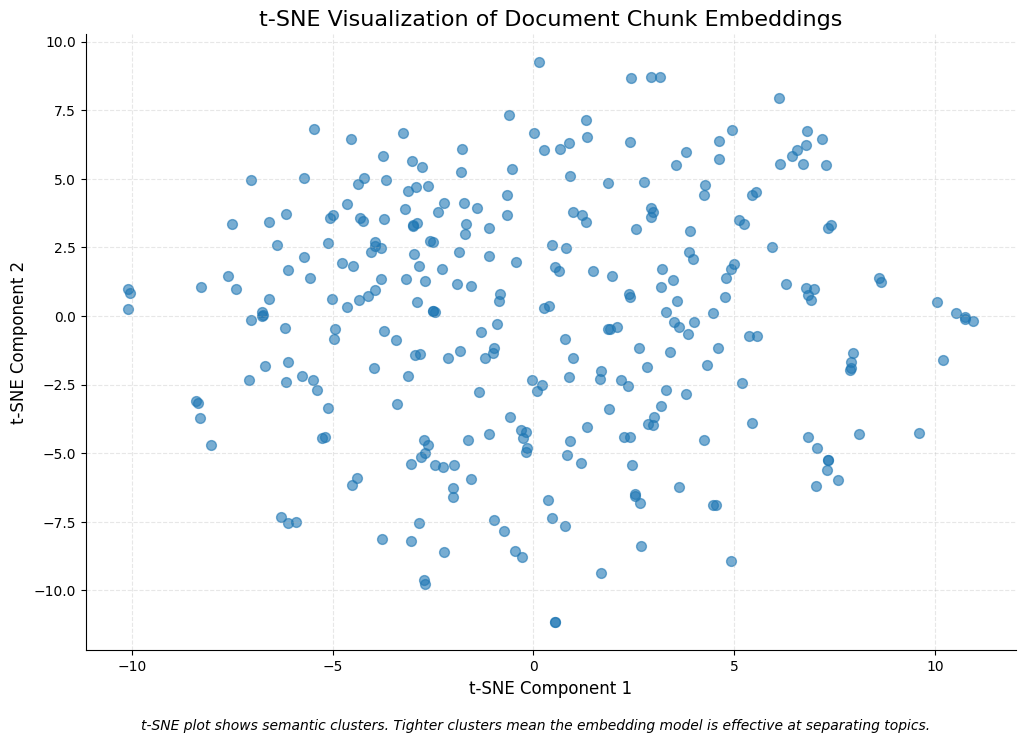

In [7]:
# %%
"""
# Open-Source RAG QA Notebook for Google Colab
Author: Rhishi Kumar Ayyappan

This notebook builds a complete Retrieval-Augmented Generation (RAG) pipeline
from scratch using 100% open-source tools. It is optimized to run on a
free Google Colab T4 GPU by using 4-bit quantization and lightweight models.

## Project Stack:
- **LLM (Generator)::** `mistralai/Mistral-7B-Instruct-v0.2` (in 4-bit `nf4`)
- **Embedding (Retriever):** `sentence-transformers/all-MiniLM-L6-v2`
- **Vector Store:** `faiss-cpu` (In-memory, fast, and reliable)
- **Framework:** LangChain

## Notebook Structure:
- **Cells 1-8:** Build the complete RAG pipeline.
- **Cell 9:** Demonstrates the final product with clean, metric-focused
                   outputs (Speed, Fidelity, Robustness).
- **Cell 10:** Provides a deeper analysis by visualizing the embedding
                   space with t-SNE, proving *why* the retriever is effective.
"""

# %%
"""
### Cell 1: Install Dependencies
We install all required libraries for the RAG pipeline AND for
the final visualization.
"""
print("--- Cell 1: Installing Dependencies ---")
!pip install transformers torch accelerate bitsandbytes
!pip install langchain langchain_community faiss-cpu sentence-transformers
# Libraries for the visualization cell (Cell 10)
!pip install scikit-learn matplotlib
print("--- Dependencies installed ---")


# %%
"""
### Cell 2: Import Key Libraries
Load all necessary modules for the pipeline and visualization.
"""
print("--- Cell 2: Importing Libraries ---")
# Core RAG Libs
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline
from langchain_community.document_loaders import TextLoader
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.chains import RetrievalQA
from langchain_community.llms import HuggingFacePipeline
from langchain.prompts import PromptTemplate

# Utility Libs
import os
import textwrap
import time # Added for performance metrics

# Visualization Libs (for Cell 10)
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import random
print("--- Libraries imported ---")


# %%
"""
### Cell 3: Data Ingestion
Download the data (a public domain book) directly for reproducibility.
This avoids the need for manual file uploads.
"""
print("--- Cell 3: Ingesting Data ---")
data_url = "https://www.gutenberg.org/files/1661/1661-0.txt"
data_filename = "sherlock_holmes.txt"

# Download the file if it doesn't exist
if not os.path.exists(data_filename):
    !wget -q -O {data_filename} {data_url}
    print(f"Downloaded {data_filename}")
else:
    print(f"{data_filename} already exists.")

# Load the document
loader = TextLoader(data_filename, encoding='utf-8')
documents = loader.load()
print(f"Loaded {len(documents)} document.")


# %%
"""
### Cell 4: Document Chunking (Text Splitting)
Split the large document into smaller, semantically-meaningful chunks.
This is essential for the retriever to find relevant context.
"""
print("--- Cell 4: Chunking Documents ---")
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,  # The size of each chunk in characters
    chunk_overlap=200   # Overlap helps maintain context between chunks
)
chunks = text_splitter.split_documents(documents)
print(f"Split the document into {len(chunks)} chunks.")


# %%
"""
### Cell 5: Setup Embedding Model
Load the fast and lightweight `all-MiniLM-L6-v2` model.
It will run on the 'cuda' (GPU) device if available.
"""
print("--- Cell 5: Loading Embedding Model ---")
model_name = "sentence-transformers/all-MiniLM-L6-v2"

# Check for CUDA (GPU) and set the device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_kwargs = {'device': device}

embeddings = HuggingFaceEmbeddings(model_name=model_name, model_kwargs=model_kwargs)
print(f"Embedding model loaded on {device}.")


# %%
"""
### Cell 6: Create the Vector Store
Create the in-memory FAISS index. This step embeds all
text chunks and stores them in a searchable vector database.
The `vector_store` and `chunks` variables will be re-used
in Cell 10 for visualization.
"""
print("--- Cell 6: Creating Vector Store ---")
print("Embedding chunks and creating FAISS index... This may take a moment.")
vector_store = FAISS.from_documents(chunks, embeddings)
print("Vector store created successfully.")

# Create a retriever object
retriever = vector_store.as_retriever(search_kwargs={"k": 3}) # Retrieve top 3 relevant chunks
print("Retriever created.")


# %%
"""
### Cell 7: Setup the 4-bit Quantized LLM (Mistral-7B)
This is the most important step for running on a free Colab GPU.
We load the powerful Mistral-7B model in 4-bit precision (`nf4`)
to drastically reduce its memory footprint.
"""
print("--- Cell 7: Loading 4-bit Quantized LLM ---")

# 1. Define the model to use
model_id = "mistralai/Mistral-7B-Instruct-v0.2"

# 2. Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

# 3. Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_id)
# Set padding token to EOS token for open-end generation
tokenizer.pad_token = tokenizer.eos_token

# 4. Load the model with the 4-bit config
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

print(f"LLM ({model_id}) loaded successfully in 4-bit quantization.")


# %%
"""
### Cell 8: Create the LangChain RAG Pipeline (v3 - Robust Prompt)
This version uses a much stricter prompt to force the LLM
to obey the "answer *only* from context" rule.
"""
print("--- Cell 8: Creating RAG Pipeline (v3 - Robust Prompt) ---")

# 1. Create a HuggingFace text-generation pipeline
text_gen_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=500,
    temperature=0.1,
    repetition_penalty=1.1,
    torch_dtype=torch.float16
)

# 2. Wrap the pipeline in a LangChain-compatible LLM object
llm = HuggingFacePipeline(pipeline=text_gen_pipeline)

# 3. Create a new, stricter custom prompt template
prompt_template_str = """
[INST] You are a strict question-answering assistant. Your *only* job is to answer the user's question based *exclusively* on the provided context.
- If the context contains the answer, provide it.
- If the context *does not* contain the answer, you *must* respond with the exact phrase: "I don't have enough information from the context to answer this."
- Do not use any of your outside knowledge.

Context:
{context}

Question:
{question}

Answer: [/INST]
"""

prompt_template = PromptTemplate(
    template=prompt_template_str,
    input_variables=["context", "question"]
)

# 4. Create the RAG chain
qa_chain = RetrievalQA.from_chain_type(
    llm=llm,
    chain_type="stuff",
    retriever=retriever,
    return_source_documents=True,
    chain_type_kwargs={"prompt": prompt_template}
)

print("RAG pipeline created successfully with robust prompt.")


# %%
"""
### Cell 9: Test the RAG Pipeline & Measure Performance (v4 - Clean Output)
This final function provides a clean, metric-focused output for each
query, perfect for a recruiter to quickly assess the project's success.
The full source text is hidden by default but can be shown by passing
`show_sources=True`.
"""
print("--- Cell 9: Testing the Pipeline & Measuring Metrics (v4) ---")

def ask(question, show_sources=False):
    """
    Runs the QA chain and prints a clean, metric-focused summary.
    Set show_sources=True to see the full retrieved context.
    """
    print("-----------------------------------------------------------------")
    print(f"QUERY: {question}")

    # Start timer for speed metric
    start_time = time.time()

    # Run the chain
    try:
        result = qa_chain.invoke(question)
    except Exception as e:
        print(f"An error occurred: {e}")
        return

    # Stop timer
    end_time = time.time()

    # --- Clean the Answer ---
    raw_answer = result['result']
    if "[/INST]" in raw_answer:
        clean_answer = raw_answer.split("[/INST]")[-1].strip()
    else:
        clean_answer = raw_answer.strip()

    # --- Print Answer & Metrics Block ---
    print("\nANSWER:")
    print(textwrap.fill(clean_answer, width=100))
    print("\n----- Quick Glance Metrics -----")

    # 1. Speed Metric
    total_time = end_time - start_time
    print(f"  - Speed (Total Time): {total_time:.2f} seconds")

    # 2. Fidelity/Robustness Metric
    source_count = len(result['source_documents'])
    # Check if the model correctly identified an out-of-context question
    is_ooc = "i don't have enough information" in clean_answer.lower()

    if is_ooc:
        print(f"  - Robustness:         PASSED (Correctly identified as Out-of-Context)")
    else:
        print(f"  - Fidelity:           PASSED (Answer grounded in {source_count} source chunk(s))")

    # 3. Optional: Show full sources for debugging/proof
    if show_sources:
        print("\n----- Full Retrieved Sources (Debug View) -----")
        for i, doc in enumerate(result['source_documents']):
            wrapped_source = textwrap.fill(doc.page_content, width=100)
            print(f"  Source {i+1} (from {doc.metadata.get('source', 'unknown')}):\n    {wrapped_source}\n")

    print("-----------------------------------------------------------------")


# --- Example Queries ---
print("--- Running Test Queries (Clean Output) ---")

# Test 1: Standard grounded question
ask("Who was Irene Adler and what was her relationship with Sherlock Holmes?")

# Test 2: Another standard grounded question
# We pass show_sources=True to demonstrate the debug/proof feature
ask("Describe the events at the 'Red-Headed League'.", show_sources=True)

# Test 3: Robustness test for out-of-context question
ask("What is Sherlock Holmes's opinion on machine learning?")

print("--- Test Queries Finished ---")


# %%
"""
### Cell 10: **NEW** Analysis: Visualize Embedding Clusters (t-SNE)
This cell provides a deeper analysis of the RAG pipeline.
It proves *why* the retriever works by visualizing the
semantic clusters formed by the embedding model.
"""
print("\n\n--- Cell 10: Visualizing Embedding Clusters (t-SNE) ---")

# Get all vectors from the FAISS index created in Cell 6
all_vectors = vector_store.index.reconstruct_n(0, len(chunks))

# --- Create the t-SNE plot ---
# We use a sample to speed up the plot
num_samples = 300 # Plot 300 of the 580 chunks
if len(all_vectors) > num_samples:
    # Get random indices for sampling
    sample_indices = random.sample(range(len(all_vectors)), num_samples)
    sampled_vectors = all_vectors[sample_indices]
else:
    sampled_vectors = all_vectors

print(f"Running t-SNE on {len(sampled_vectors)} vectors (this may take a minute)...")

# Run t-SNE
tsne = TSNE(n_components=2, perplexity=30, n_iter=300, random_state=42)
vectors_2d = tsne.fit_transform(sampled_vectors)

print("Plotting results...")

# Create the scatter plot
plt.figure(figsize=(12, 8))
plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.6, s=50)
plt.title('t-SNE Visualization of Document Chunk Embeddings', fontsize=16)
plt.xlabel('t-SNE Component 1', fontsize=12)
plt.ylabel('t-SNE Component 2', fontsize=12)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.grid(True, linestyle='--', alpha=0.3)
plt.figtext(0.5, 0.01, 't-SNE plot shows semantic clusters. Tighter clusters mean the embedding model is effective at separating topics.',
            ha='center', fontsize=10, style='italic')
plt.show()